In [1]:
import warnings
warnings.filterwarnings("ignore")


### Cell 1: Text Preprocessing & Cleaning


In [2]:
import pandas as pd
import re
import string

def remove_punctuation(text):
    if pd.isna(text): return text
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_whitespace(text):
    if pd.isna(text): return text
    return " ".join(text.split())

def remove_emojis(text):
    if pd.isna(text): return text
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_urls(text):
    if pd.isna(text): return text
    return re.compile(r'https?://\S+|www\.\S+').sub(r'', text)

def remove_html(text):
    if pd.isna(text): return text
    return re.compile(r'<.*?>').sub(r'', text)

def remove_special_characters(text):
    if pd.isna(text): return text
    return re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF]', '', text)

def clean_text(text):
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    return text

csv_paths = {
    'Train': '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv',
    'Val':   '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv',
    'Test':  '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv'
}

cleaned_output_paths = {
    'Train': '/kaggle/working/train_cleaned.csv',
    'Val':   '/kaggle/working/val_cleaned.csv',
    'Test':  '/kaggle/working/test_cleaned.csv'
}

for key in csv_paths:
    df = pd.read_csv(csv_paths[key])
    df['Title'] = df['Title'].astype(str).apply(clean_text)
    df['label'] = df['label'].astype(int)
    df.to_csv(cleaned_output_paths[key], index=False)
    print(f"Cleaned {key} shape: {df.shape}")
    print(df.head(2))
    print()


Cleaned Train shape: (5002, 14)
   SL. NO.                     Image Path  \
0        1  Thumbnails/thumbnail_9062.jpg   
1        2  Thumbnails/thumbnail_8722.jpg   

                                               Title  \
0  ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...   
1  ২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...   

                                           URL   Source  label Category  \
0   https://www.youtube.com/shorts/v9I2zu5zyqc  YouTube      1      NaN   
1  https://www.youtube.com/watch?v=eLaE8u3AbZU  YouTube      0      NaN   

      Video ID YouTube Channel  Like    View Comment Count Upload Date  \
0          NaN             NaN   NaN     NaN           NaN         NaN   
1  eLaE8u3AbZU   amar i school   5.0  1477.0    1899-12-30   4/25/2025   

  Current Date  
0          NaN  
1     5/3/2025  

Cleaned Val shape: (715, 14)
   SL. NO.                      Image Path  \
0        1   Thumbnails/thumbnail_6549.jpg   
1        2  Thumbnails/thumbnail_14236.jp

### Cell 2: Preview Cleaned Splits


In [3]:
train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
train_df.head()


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_9062.jpg,ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...,https://www.youtube.com/shorts/v9I2zu5zyqc,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Thumbnails/thumbnail_8722.jpg,২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...,https://www.youtube.com/watch?v=eLaE8u3AbZU,YouTube,0,NaN,eLaE8u3AbZU,amar i school,5.0,1477.0,1899-12-30,4/25/2025,5/3/2025
2,3,Thumbnails/thumbnail_13793.jpg,চ্যালেঞ্জ সামলাতে পারবে যুক্তরাষ্ট্রের সাথে সম...,https://www.youtube.com/watch?v=7dC06fs4wb4,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Thumbnails/thumbnail_15025.jpg,কুমির চাষে আয় ১৫ কোটি টাকা না দেখলে বিশ্বাস ক...,https://www.youtube.com/watch?v=XDQppsld1dQ,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Thumbnails/thumbnail_13884.jpg,আ লীগ নির্বাচনে থাকবে কিনা সিদ্ধান্ত কার ওপর ছ...,https://www.youtube.com/watch?v=TV9y4kWe7F8,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
val_df = pd.read_csv('/kaggle/working/val_cleaned.csv')
val_df.head()


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_6549.jpg,হাসিনার প্লট জালিয়াতি ফাঁসছেন ২০ কর্মকর্তা DU...,https://www.youtube.com/watch?v=s_hKGdmMoJI,YouTube,0,NaN,s_hKGdmMoJI,SOMOY TV,173.0,13964.0,1/14/1900,4/18/2025,5/3/2025
1,2,Thumbnails/thumbnail_14236.jpg,কক্সবাজারে এনসিপি নেতাদের গাড়িবহরে হামলা Coxs...,https://www.youtube.com/watch?v=ijG29YTAFtM,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Thumbnails/thumbnail_13301.jpg,WBCHSE 2025 Results LIVE উচ্চমাধ্যমিকের ফলাফল ...,https://www.youtube.com/watch?v=7OAWOzTYFzc,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Thumbnails/thumbnail_6204.jpg,কাল থেকে পুরোদমে শুরু হচ্ছে দেশের শিক্ষা কার্য...,https://www.youtube.com/watch?v=1-2oqaRnh5M,YouTube,1,NaN,1-2oqaRnh5M,Maasranga News,1.0,134.0,1899-12-30,8/17/2024,5/3/2025
4,5,Thumbnails/thumbnail_5862.jpg,নবম শ্রেণীর পাঠ্যবই নিয়ে যে তথ্য দিলেন আসিফ ম...,https://www.youtube.com/watch?v=2pu4xEKPY_Y,YouTube,0,NaN,2pu4xEKPY_Y,SOMOY TV,18928.0,532054.0,3/3/1905,12/21/2024,5/3/2025


In [5]:
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')
test_df.head()


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_2775.jpg,অহংকারের পরিণতি কি মুফতি সাইফুল্লাহ মাহমুদআল্ল...,https://www.youtube.com/watch?v=9kVCpUrQnVQ,YouTube,0,NaN,9kVCpUrQnVQ,AKL ISLAMiC TV,2.0,83.0,1899-12-30,8/25/2022,5/3/2025
1,2,Thumbnails/thumbnail_12266.jpg,ইলেকট্রিক কেটলিতে পানি গরম করলে কত টাকা বিদ্যু...,https://www.youtube.com/watch?v=8veISEBD70k,YouTube,1,8veISEBD70k,Electricity for Life,14,716.0,2.0,12/19/2024,5/3/2025,Unavailable
2,3,Thumbnails/thumbnail_11645.jpg,বনসংরক্ষণ প্রবন্ধ রচনা মাধ্যমিক ও উচ্চমাধ্যমিক...,https://www.youtube.com/watch?v=i8Wf7KbC3g4,YouTube,0,NaN,i8Wf7KbC3g4,Scene Create,0.0,35.0,1899-12-30,2/12/2025,5/3/2025
3,4,Thumbnails/thumbnail_8109.jpg,টপ ৫ ইতিহাসের সবচেয়ে ভয়াবহ প্রাকৃতিক দুর্যোগ...,https://www.youtube.com/watch?v=sw6UVbHGMPU,YouTube,1,NaN,sw6UVbHGMPU,FactsBD,123.0,13158.0,1/2/1900,11/3/2021,5/3/2025
4,5,Thumbnails/thumbnail_3045.jpg,পাকিস্তানিরা কেন শেখ মুজিবের চেয়ে তাজউদ্দীনকে...,https://www.youtube.com/watch?v=PtOrfve9MUs,YouTube,1,NaN,PtOrfve9MUs,Enayet Chowdhury,33797.0,1319163.0,3/24/1908,12/5/2023,5/3/2025


### Cell 3: Install Dependencies


In [6]:
!pip install transformers


### Cell 4: Imports & Configuration


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertModel,
    AutoImageProcessor, ViTModel
)
import pandas as pd
from PIL import Image
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# ================================
# Configuration Class
# ================================
class Config:
    # Cleaned CSV Paths
    TRAIN_CSV = '/kaggle/working/train_cleaned.csv'
    VAL_CSV   = '/kaggle/working/val_cleaned.csv'
    TEST_CSV  = '/kaggle/working/test_cleaned.csv'

    # Image Folder
    IMAGE_FOLDER = '/kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails'

    # Hyperparameters
    MAX_LEN       = 64
    BATCH_SIZE    = 32
    EPOCHS        = 15
    LEARNING_RATE = 2e-5
    DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Model Names
    TEXT_MODEL  = 'bert-base-multilingual-cased'   # mBERT
    IMAGE_MODEL = 'google/vit-base-patch16-224'     # ViT

print(f"Device set to: {Config.DEVICE}")


Device set to: cuda


### Cell 5: Custom Dataset Class


In [13]:
class ClickbaitDataset(Dataset):
    def __init__(self, csv_path, tokenizer, feature_extractor):
        self.df                = pd.read_csv(csv_path)
        self.tokenizer         = tokenizer
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- 1. Image Processing ---
        img_filename = os.path.basename(str(row['Image Path']).strip())
        img_path     = os.path.join(Config.IMAGE_FOLDER, img_filename)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        pixel_values = self.feature_extractor(
            images=image, return_tensors='pt'
        )['pixel_values'].squeeze(0)  # (3, 224, 224)

        # --- 2. Text Processing ---
        text     = str(row['Title'])
        encoding = self.tokenizer(
            text,
            max_length=Config.MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'pixel_values':  pixel_values,
            'input_ids':     encoding['input_ids'].flatten(),
            'attention_mask':encoding['attention_mask'].flatten(),
            'token_type_ids':encoding['token_type_ids'].flatten(),
            'label':         torch.tensor(int(row['label']), dtype=torch.long)
        }


### Cell 6: Model Architecture — ViT + mBERT Intermediate Fusion


In [14]:
class ViT_mBERT_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super(ViT_mBERT_Fusion, self).__init__()

        # --- Image Encoder: ViT-Base ---
        self.image_encoder = ViTModel.from_pretrained(Config.IMAGE_MODEL)
        self.img_out_dim   = 768  # ViT-Base hidden size

        # --- Text Encoder: mBERT ---
        self.text_encoder = BertModel.from_pretrained(Config.TEXT_MODEL)
        self.text_out_dim = 768  # mBERT hidden size

        # --- Intermediate Fusion Head ---
        fusion_dim = self.img_out_dim + self.text_out_dim  # 1536

        self.fusion_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids):
        # 1. Image Features — [CLS] token from ViT
        img_outputs   = self.image_encoder(pixel_values=pixel_values)
        img_features  = img_outputs.last_hidden_state[:, 0, :]   # (B, 768)

        # 2. Text Features — [CLS] token from mBERT
        text_outputs  = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        text_features = text_outputs.last_hidden_state[:, 0, :]  # (B, 768)

        # 3. Concatenate (Intermediate Fusion)
        combined = torch.cat((img_features, text_features), dim=1)  # (B, 1536)

        # 4. Classification
        logits = self.fusion_head(combined)
        return logits


### Cell 7: Setup Data Loaders


In [15]:
tokenizer         = BertTokenizer.from_pretrained(Config.TEXT_MODEL)
feature_extractor = AutoImageProcessor.from_pretrained(Config.IMAGE_MODEL)
train_dataset = ClickbaitDataset(Config.TRAIN_CSV, tokenizer, feature_extractor)
val_dataset   = ClickbaitDataset(Config.VAL_CSV,   tokenizer, feature_extractor)
test_dataset  = ClickbaitDataset(Config.TEST_CSV,  tokenizer, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Train batches: 157
Val   batches: 23
Test  batches: 45


### Cell 8: Training & Evaluation Functions


In [16]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(dataloader, desc="Training"):
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values, input_ids, attention_mask, token_type_ids)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            pixel_values   = batch['pixel_values'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(pixel_values, input_ids, attention_mask, token_type_ids)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(dataloader), accuracy, all_labels, all_preds


### Cell 9: Main Training Loop


In [17]:
model     = ViT_mBERT_Fusion(num_classes=2).to(Config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

best_acc = 0
print("Starting Training...")

for epoch in range(Config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")

    train_loss, train_acc          = train_epoch(model, train_loader, criterion, optimizer, Config.DEVICE)
    val_loss, val_acc, _, _        = eval_model(model, val_loader,   criterion, Config.DEVICE)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_vit_mbert_fusion.pth')
        print(">>> Model Saved!")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

Train Loss: 0.0403 | Train Acc: 0.9864
Val   Loss: 1.0227 | Val   Acc: 0.7860

Epoch 14/15


Evaluating: 100%|██████████| 23/23 [00:11<00:00,  2.08it/s]


Train Loss: 0.0348 | Train Acc: 0.9876
Val   Loss: 1.0917 | Val   Acc: 0.8056

Epoch 15/15


Evaluating: 100%|██████████| 23/23 [00:11<00:00,  2.08it/s]

Train Loss: 0.0400 | Train Acc: 0.9864
Val   Loss: 1.1863 | Val   Acc: 0.7762


### Cell 10: Test Evaluation & Metrics


Loading Best Model for Testing...


Evaluating: 100%|██████████| 45/45 [00:21<00:00,  2.05it/s]



       FINAL TEST RESULTS       
Accuracy:  0.8175
Precision: 0.8221
Recall:    0.7256
F1 Score:  0.7709
------------------------------

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Clickbait       0.81      0.88      0.85       825
    Clickbait       0.82      0.73      0.77       605

     accuracy                           0.82      1430
    macro avg       0.82      0.81      0.81      1430
 weighted avg       0.82      0.82      0.82      1430



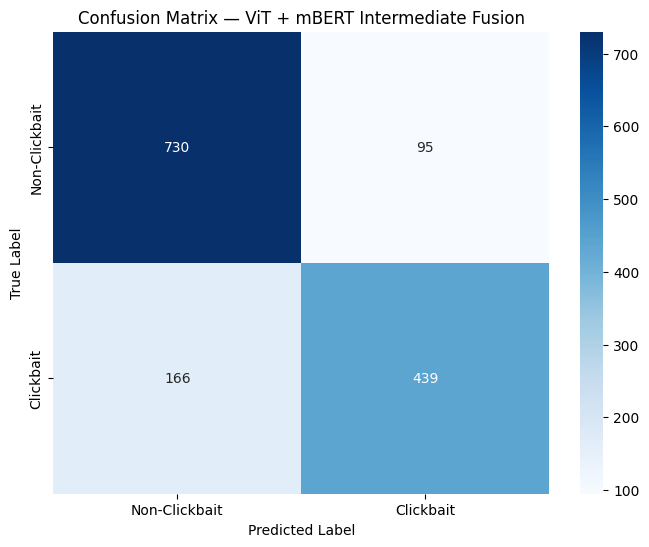

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("Loading Best Model for Testing...")
model.load_state_dict(torch.load('best_vit_mbert_fusion.pth', map_location=Config.DEVICE))

test_loss, test_acc, true_labels, pred_labels = eval_model(model, test_loader, criterion, Config.DEVICE)

precision   = precision_score(true_labels, pred_labels, average='binary')
recall      = recall_score(true_labels, pred_labels, average='binary')
f1          = f1_score(true_labels, pred_labels, average='binary')
conf_matrix = confusion_matrix(true_labels, pred_labels)

print("\n" + "="*30)
print("       FINAL TEST RESULTS       ")
print("="*30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("-"*30)
print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Non-Clickbait', 'Clickbait']))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — ViT + mBERT Intermediate Fusion')
plt.show()


### Cell 11: ROC Curve


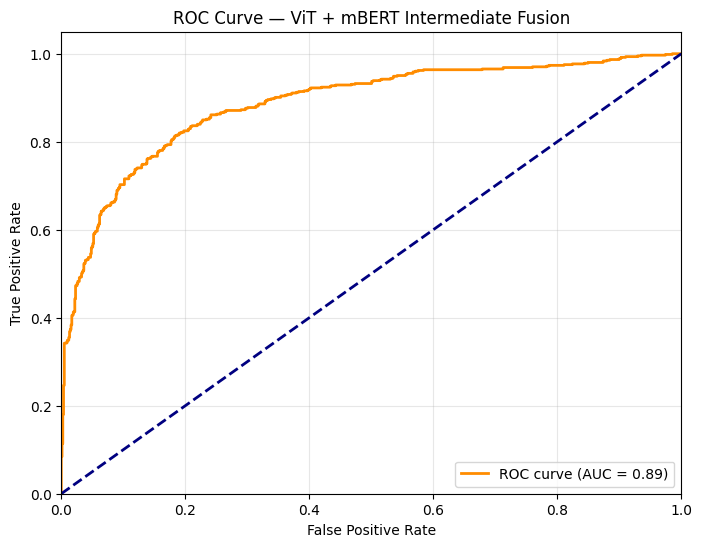

In [19]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, data_loader, device):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in data_loader:
            pixel_values   = batch['pixel_values'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(pixel_values, input_ids, attention_mask, token_type_ids)
            probs   = F.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — ViT + mBERT Intermediate Fusion')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

model.load_state_dict(torch.load('best_vit_mbert_fusion.pth', map_location=Config.DEVICE))
plot_roc_curve(model, test_loader, Config.DEVICE)
